---
title: "Get Started with Predictive Distribution"
description: "Learn how to extract predictive distributions with TabPFNRegressor"
cookbookTags:
  - regression
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---

*Going beyond point estimates to the full predictive distribution.*

A TabPFN regressor does not just output a single number per row. It predicts a full distribution over the target, which we can summarise as a mean, read off at chosen quantiles, or visualise directly. To generate point-estimates the `TabPFNRegressor` object takes the mean of the predicted distribution.

 This notebook captures that full output, inspects its structure, and uses it to draw calibrated uncertainty bands around the model's predictions. We run the regressor through the hosted API client (`tabpfn-client`); the same code works with the local `tabpfn` package by changing the import.

## Setup

*Installing the TabPFN client and the plotting dependencies.*

In [ ]:
!pip install tabpfn tabpfn-client matplotlib numpy scikit-learn

## Imports and Data

*Loading the diabetes dataset and the distribution plotting helper.*

The regressor comes from the hosted client (`tabpfn_client`). Alongside it we import `plot_regression_distribution` from the open-source `tabpfn` package, a helper that draws TabPFN's predicted distribution for a single sample.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from google.colab import userdata
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from tabpfn_client import TabPFNRegressor
from tabpfn.visualisation import plot_regression_distribution


X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

## Authenticating with a Token

*Setting `TABPFN_TOKEN` so the client can reach the API.*

In [2]:
from tabpfn_client import set_access_token
set_access_token(userdata.get('TABPFN_TOKEN'))

## Fit the Regressor

*A small ensemble keeps the full-distribution output light.*

Each estimator contributes its own predicted distribution, and the final output combines them. We use four here.

In [3]:
reg = TabPFNRegressor(n_estimators=4)
_ = reg.fit(X_train, y_train)

## Capturing the Full Output

*Requesting `output_type="full"` returns a dictionary, not an array.*

Instead of one prediction per row, the full output exposes every summary TabPFN computes, keyed by name.

In [4]:
preds = reg.predict(X_test, output_type="full")
preds.keys()  # preds are a dictionary

dict_keys(['mean', 'median', 'mode', 'quantiles', 'logits', 'borders', 'criterion'])

## Inspecting the Output

*The mean and the predicted quantiles, side by side.*

`mean` holds the point estimate per row. `quantiles` holds the predicted value at each default quantile, from the 10th to the 90th percentile.

In [5]:
preds["mean"]

array([261.16992188, 246.28448486, 156.26689148, 121.78527832,
       169.63705444, 258.46777344, 102.88179779, 205.09663391,
       142.33389282, 235.75292969, 173.13687134, 187.27841187,
       104.72064972, 103.30994415, 270.23266602,  79.95400238,
       152.24006653,  75.66131592, 113.61773682, 232.30451965,
       192.88079834, 147.43656921, 159.11346436, 129.84512329,
       195.90155029, 162.16201782, 116.79338074,  83.20404053,
       181.80780029, 157.69380188, 185.97906494,  86.308815  ,
       141.29656982, 167.90930176, 139.98382568, 192.90596008,
       177.07931519, 176.54196167, 113.73403931, 203.78274536,
        99.73474121, 154.33691406, 141.83346558, 185.01683044,
       175.8578949 ,  85.73569489, 130.54496765, 121.97619629,
       109.46016693, 241.55599976, 151.43585205,  77.43727112,
       137.65100098, 161.75325012, 239.99275208, 166.02326965,
       186.83798218, 110.79470825, 131.02799988, 179.75619507,
       219.80897522, 150.10687256, 145.29524231, 104.30

In [6]:
# default quantiles are: [0.1, 0.2, ..., 0.8, 0.9]
# the shape of the quantiles array is quantiles x rows
preds["quantiles"].shape

(9, 89)

## Visualising a Single Prediction

*Plotting the full predicted distribution for one row.*

`plot_regression_distribution` shows the shape of the distribution TabPFN assigns to a single sample, making its confidence, or lack of it, visible at a glance.

<Axes: title={'center': 'TabPFN predicted distribution'}, xlabel='Predicted target', ylabel='Probability density'>

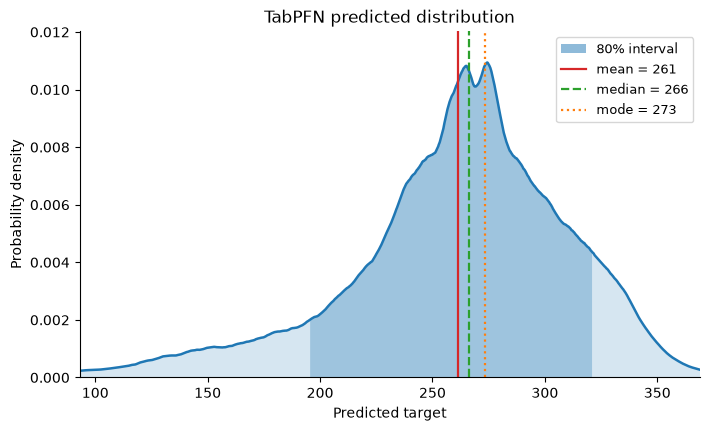

In [7]:
preds["logits"] = torch.as_tensor(np.nan_to_num(np.asarray(preds["logits"]), nan=-np.inf))
plot_regression_distribution(preds, sample_idx=0)

![Predicted distribution for sample 0](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/predictive_distribution/sample-prediction-0.png)


<Axes: title={'center': 'TabPFN predicted distribution'}, xlabel='Predicted target', ylabel='Probability density'>

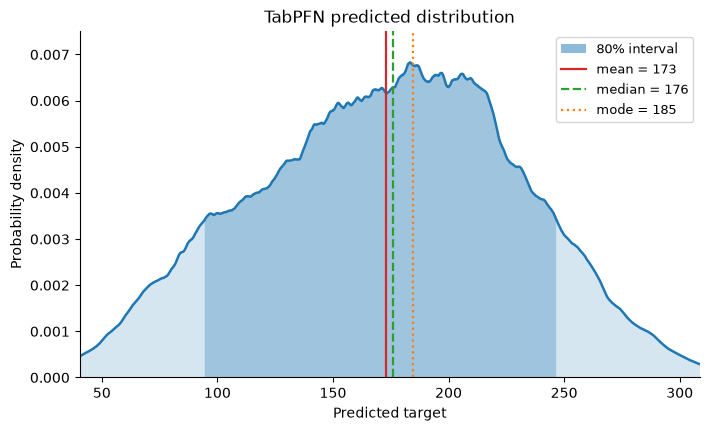

In [8]:
plot_regression_distribution(preds, sample_idx=10)

![Predicted distribution for sample 10](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/predictive_distribution/sample-prediction-10.png)


## Uncertainty Across the Input Range

*Building an uncertainty band on a controlled synthetic dataset.*

To see how the input affects the uncertainty in the prediction, we generate data where the noise grows with the input.

### Generate the data

*A linear trend with noise that widens as X grows.*

In [9]:
n_train = 100
n_test = 50
rng = np.random.default_rng(0)
X_train = rng.uniform(0.0, 10.0, size=n_train)
y_train = 2 * X_train + rng.uniform(size=n_train) * X_train
X_train = X_train.reshape(-1,1)
X_test = np.linspace(10.0, 20.0, n_test, dtype=np.float32).reshape(-1, 1)

### Generate predictions

*Mean predictions, plus the full distribution for the quantiles.*

In [10]:
reg = TabPFNRegressor()
reg.fit(X_train, y_train)
preds = reg.predict(X_test) # mean point-estimates
full_preds = reg.predict(X_test, output_type="full")

### Plot the uncertainty band

*Shading between the 10th and 90th predicted quantiles.*

The band widens where the model is less certain, including the extrapolation region past the training data.

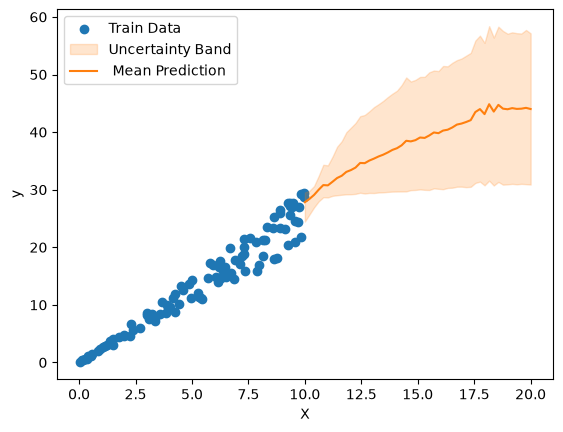

In [11]:
# @title
q10 = full_preds["quantiles"][0]
q90 = full_preds["quantiles"][-1]

plt.scatter(X_train, y_train, label="Train Data")
plt.fill_between(X_test.flatten(), q10, q90, alpha=0.2, color="C1", label="Uncertainty Band")
plt.plot(X_test, preds, color="C1", label=" Mean Prediction")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

![Uncertainty band plot](https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/visuals/predictive_distribution/uncertainty-band.png)
